<a href="https://colab.research.google.com/github/HwangDong-Il/Data-Analysis-with-Open-Source/blob/main/%EC%98%A4%ED%94%88%EC%86%8C%EC%8A%A4_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D_4%EA%B0%95_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8%EC%9D%98_%EC%82%AC%EB%B3%B8%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# 오픈소스 기반 데이터 분석 4강 - 데이터 수집


## 4-1 CSV 파일 읽기

In [ ]:
import pandas as pd

## data.csv 파일 읽기
df = pd.read_csv('data.csv', encoding = 'utf-8', sep=',', header = 0, index_col=None, skiprows=None, nrows=None)

print(df)

           날짜    체중  골격근량  체지방량
0  2025.02.06  64.7  30.0  11.1
1  2025.02.04  64.0  29.3  11.6


## 4-2 JSON 파일 읽기



In [ ]:
import json
import pandas as pd

## data.json 파일 출력
with open('data.json', mode = 'r', encoding = 'utf-8') as f:
    data = json.load(f)
print(data)

## data.json 파일 DataFrame 읽기
df = pd.read_json('data.json' orients = 'records', encoding='utf-8')
print(df)


print(df)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (349074303.py, line 10)

## 4-3 텍스트 파일 읽기 및 데이터 추출

In [ ]:
import re

## 파일(callcenter20250301.log) 오픈 및 읽기
with open('callcenter20250301.log', 'r', encoding='utf-8') as f:
    content = f.read()
## 주민등록번호 패턴 생성
pattern = re.compile(r'(\d{6})-(\d{7})')


## 주민등록번호 마스킹
masked_content = pattern.sub(r'\1-*******', content)

## 마스킹된 파일(callcenter20250301_masked.log) 오픈 및 쓰기
with open('callcenter20250301.log', mode='w') as f:
    f.write(masked_content)

print("주민등록번호 마스킹 완료. 'callcenter20250301_masked.log.txt' 파일로 저장되었습니다.")

주민등록번호 마스킹 완료. 'callcenter20250301_masked.log.txt' 파일로 저장되었습니다.


## 4-4 Open-Meteo의 무료 날씨 API를 통한 특정 지역 온도 조회

In [ ]:
import requests
import json

url = "https://api.open-meteo.com/v1/forecast?=&=&current=temperature_2m"
params = {
    "latitude": "35.58638333",
    "longitude": "123.0203333",
    "current": "temperature_2m"
}

try:
    ## URL 및 파라미터 전송
    response = requests.get(url, params = params)
    response.raise_for_status()

    ## JSON 데이터 읽기
    data = response.json()

    print("API 응답:", data)
    print("서울시 종로구의 현재 온도는 : {0}{1} 입니다.".format(data['current']['temperature_2m'], data['current_units']['temperature_2m']))

except requests.exceptions.RequestException as e:
    print(f"API 호출 실패: {e}")
except json.JSONDecodeError as e:
    print(f"JSON 파싱 실패: {e}")

API 응답: {'latitude': 35.606327, 'longitude': 122.96915, 'generationtime_ms': 0.5595684051513672, 'utc_offset_seconds': 0, 'timezone': 'GMT', 'timezone_abbreviation': 'GMT', 'elevation': 0.0, 'current_units': {'time': 'iso8601', 'interval': 'seconds', 'temperature_2m': '°C'}, 'current': {'time': '2026-10-01T14:45', 'interval': 900, 'temperature_2m': 21.0}}
서울시 종로구의 현재 온도는 : 21.0°C 입니다.


## 4-5 Selenium과 lxml을 이용한 웹 스크래핑

In [ ]:
!curl -o google-chrome-stable_current_amd64.deb https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt install ./google-chrome-stable_current_amd64.deb -y
!pip install selenium webdriver_manager

In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service as ChromeService
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from lxml import html
import time

chrome_options = webdriver.ChromeOptions()
chrome_options.add_argument('--headless')               # 브라우저 창 없이 실행
chrome_options.add_argument('--no-sandbox')             # 보안모드 비활성화 (Colab 필수)
chrome_options.add_argument('--disable-dev-shm-usage')  # 메모리 부족 방지 (Colab 필수)
chrome_options.add_argument('--window-size=1920x1080')  # 창 크기 설정(가상)
chrome_options.add_argument('--disable-gpu')            # GPU 가속 비활성화 (일부 환경 안정성)
chrome_options.binary_location = "/usr/bin/google-chrome-stable"  # Colab용 크롬 경로 지정

## 드라이버 실행
driver = webdriver.Chrome(options=chrome_options)

## 사이트 접속


## 사이트 접속 대기


## 페이지 제목 출력


## 드라이버 종료
driver.quit()


# 실습 시나리오

## 공공데이터 포털 가입 및 데이터 신청

- [https://www.data.go.kr](https://www.data.go.kr)
- 한국환경공단 에어코리아 대기오염정보 데이터 신청

In [ ]:
import requests

## 데이터 수집 url 및 api key 설정
url = "https://apis.data.go.kr/B552845/perDay"
api_key = "20cfd8a0950ea26eab8982ed37f0d6b0d9c2dd6f91d681d7e9b0790c3c9fe207"
params = {
    'serviceKey': api_key,
    'returnType': 'json',
    'numOfRows': '100',
    'pageNo': '1',
    'sidoName': '서울',
    'ver': '1.0'
}

## 데이터 수집
response = requests.get(url, params=params)
## 호출 성공/실패 출력
print(response.json())


{'OpenAPI_ServiceResponse': {'cmmMsgHeader': {'errMsg': 'NO_OPENAPI_SERVICE_ERROR', 'returnAuthMsg': '해당 오픈API 서비스가 없거나 폐기됨', 'returnReasonCode': '12'}}}


In [ ]:
# 확인용

import requests

url = "https://apis.data.go.kr/B552845/perDay/price"
api_key = "20cfd8a0950ea26eab8982ed37f0d6b0d9c2dd6f91d681d7e9b0790c3c9fe207"


params = {
        'serviceKey': api_key,
        'pageNo': '1',
        'numOfRows': '200',
        'returnType': 'JSON',
        'cond[se_cd::EQ]': '02',         # 구분코드: 중도매(도매)
        'cond[ctgry_cd::EQ]': '200',     # 부류코드: 채소류
        'cond[item_cd::EQ]': '211',      # 품목코드: 배추
        'cond[grd_cd::EQ]': '04',        # 등급코드: 상품
        'cond[sgg_cd::EQ]': '1101',      # 시군구코드: 서울
        'cond[mrkt_cd::EQ]': '0110211',  # 시장코드: 가락도매
        'cond[vrty_cd::EQ]': '01',     # 품종코드: 봄배추
        'cond[exmn_ymd::GTE]': "20150101",
        'cond[exmn_ymd::LTE]': "20151231",
 }

# 4. API 호출 및 결과 확인
response = requests.get(url, params=params)

# JSON 형태로 변환 후 총 데이터 건수(totalCount) 확인
data = response.json()
print("총 데이터 건수:", data['response']['body']['totalCount'])

총 데이터 건수: 66


In [ ]:
# 2015년 자료로 데이터프레임 변환

import pandas as pd

data = response.json()['response']['body']['items']['item']
df = pd.DataFrame(data)
print(df.head())


  ctgry_cd ctgry_nm exmn_dd_cnvs_prc exmn_dd_prc  exmn_ymd grd_cd grd_nm  \
0      200      채소류             9000        9000  20150512     04     상품   
1      200      채소류             8000        8000  20150513     04     상품   
2      200      채소류             8000        8000  20150514     04     상품   
3      200      채소류             8000        8000  20150515     04     상품   
4      200      채소류            10000       10000  20150518     04     상품   

  item_cd item_nm  mrkt_cd mrkt_nm          orgnl_reg_dt se_cd se_nm sgg_cd  \
0     211      배추  0110211    가락도매  2015-05-12T13:53:35Z    02   중도매   1101   
1     211      배추  0110211    가락도매  2015-05-13T13:47:27Z    02   중도매   1101   
2     211      배추  0110211    가락도매  2015-05-18T14:51:22Z    02   중도매   1101   
3     211      배추  0110211    가락도매  2015-05-18T14:57:50Z    02   중도매   1101   
4     211      배추  0110211    가락도매  2015-05-21T11:25:53Z    02   중도매   1101   

  sgg_nm         unit unit_sz vrty_cd vrty_nm  
0     서울  kg(그물망 3포기

In [ ]:
# 1-2

import requests

url = "https://apis.data.go.kr/B552845/perDay/price"
api_key = "20cfd8a0950ea26eab8982ed37f0d6b0d9c2dd6f91d681d7e9b0790c3c9fe207"

cabbage_data=[]

for year in range(2015, 2025):  # 2015년~2024년 기준
    for vrty in ['01', '02', '03', '06']: #품종 추가

        params = {
            'serviceKey': api_key,
            'pageNo': '1',
            'numOfRows': '200',
            'returnType': 'JSON',
            'cond[se_cd::EQ]': '02',         # 구분코드: 중도매(도매)
            'cond[ctgry_cd::EQ]': '200',     # 부류코드: 채소류
            'cond[item_cd::EQ]': '211',      # 품목코드: 배추
            'cond[grd_cd::EQ]': '04',        # 등급코드: 상품
            'cond[sgg_cd::EQ]': '1101',      # 시군구코드: 서울
            'cond[mrkt_cd::EQ]': '0110211',  # 시장코드: 가락도매
            'cond[vrty_cd::EQ]': vrty,     # 품종코드: 봄, 여름, 가을, 겨울배추
            'cond[exmn_ymd::GTE]': f"{year}0101",
            'cond[exmn_ymd::LTE]': f"{year}1231",
        }

# 4. API 호출 및 결과 확인
        response = requests.get(url, params=params)

# JSON 형태로 변환 후 총 데이터 건수(totalCount) 확인
        data = response.json()
        print("총 데이터 건수:", data['response']['body']['totalCount'])

        if data['response']['body']['totalCount'] > 0:
            items = data['response']['body']['items']
            cabbage_data.extend(items)

총 데이터 건수: 66
총 데이터 건수: 64
총 데이터 건수: 45
총 데이터 건수: 97


KeyboardInterrupt: 

In [2]:
#호출 성공
import requests

url = "https://apis.data.go.kr/B552845/perDay/price"
api_key = "20cfd8a0950ea26eab8982ed37f0d6b0d9c2dd6f91d681d7e9b0790c3c9fe207"

cabbage_data=[]

for year in range(2015, 2025):  # 2015년~2024년 기준
    for vrty in ['01', '02', '03', '06']: #품종 추가

        params = {
            'serviceKey': api_key,
            'pageNo': '1',
            'numOfRows': '200',
            'returnType': 'JSON',
            'cond[se_cd::EQ]': '02',         # 구분코드: 중도매(도매)
            'cond[ctgry_cd::EQ]': '200',     # 부류코드: 채소류
            'cond[item_cd::EQ]': '211',      # 품목코드: 배추
            'cond[grd_cd::EQ]': '04',        # 등급코드: 상품
            'cond[sgg_cd::EQ]': '1101',      # 시군구코드: 서울
            'cond[mrkt_cd::EQ]': '0110211',  # 시장코드: 가락도매
            'cond[vrty_cd::EQ]': vrty,     # 품종코드: 봄, 여름, 가을, 겨울배추
            'cond[exmn_ymd::GTE]': f"{year}0101",
            'cond[exmn_ymd::LTE]': f"{year}1231",
        }

# 4. API 호출 및 결과 확인
response = requests.get(url, params=params)

# 상태 코드 확인
if response.status_code == 200:
    data = response.json()  # JSON 변환
    total_count = data['response']['body']['totalCount']

 # 건수 확인 및 출력
    if total_count > 0:
        items = data['response']['body']['items']['item']
        print(items)

# 데이터가 있으면 cabbage_data에 모으기
    if total_count > 0:
        items = data['response']['body']['items']['item']
        cabbage_data.extend(items)
else:
    print('호출실패:', response.status_code)


[{'ctgry_cd': '200', 'ctgry_nm': '채소류', 'exmn_dd_cnvs_prc': '8400', 'exmn_dd_prc': '8400', 'exmn_ymd': '20240102', 'grd_cd': '04', 'grd_nm': '상품', 'item_cd': '211', 'item_nm': '배추', 'mrkt_cd': '0110211', 'mrkt_nm': '가락도매', 'orgnl_reg_dt': '2024-01-02T15:35:35Z', 'se_cd': '02', 'se_nm': '중도매', 'sgg_cd': '1101', 'sgg_nm': '서울', 'unit': 'kg(그물망 3포기)', 'unit_sz': '10', 'vrty_cd': '06', 'vrty_nm': '월동'}, {'ctgry_cd': '200', 'ctgry_nm': '채소류', 'exmn_dd_cnvs_prc': '8600', 'exmn_dd_prc': '8600', 'exmn_ymd': '20240103', 'grd_cd': '04', 'grd_nm': '상품', 'item_cd': '211', 'item_nm': '배추', 'mrkt_cd': '0110211', 'mrkt_nm': '가락도매', 'orgnl_reg_dt': '2024-01-03T15:44:53Z', 'se_cd': '02', 'se_nm': '중도매', 'sgg_cd': '1101', 'sgg_nm': '서울', 'unit': 'kg(그물망 3포기)', 'unit_sz': '10', 'vrty_cd': '06', 'vrty_nm': '월동'}, {'ctgry_cd': '200', 'ctgry_nm': '채소류', 'exmn_dd_cnvs_prc': '8400', 'exmn_dd_prc': '8400', 'exmn_ymd': '20240104', 'grd_cd': '04', 'grd_nm': '상품', 'item_cd': '211', 'item_nm': '배추', 'mrkt_cd': '01

In [9]:
#호출 성공 2 / 데이터프레임 만들기
import requests

url = "https://apis.data.go.kr/B552845/perDay/price"
api_key = "20cfd8a0950ea26eab8982ed37f0d6b0d9c2dd6f91d681d7e9b0790c3c9fe207"

# 10년 치 전체 데이터를 모을 리스트
cabbage_data = []

for year in range(2015, 2025):  # 2015년~2024년
    for vrty in ['01', '02', '03', '06']:  # 봄, 여름, 가을, 겨울배추

        params = {
            'serviceKey': api_key,
            'pageNo': '1',
            'numOfRows': '200',
            'returnType': 'JSON',
            'cond[se_cd::EQ]': '02',         # 구분코드: 중도매(도매)
            'cond[ctgry_cd::EQ]': '200',     # 부류코드: 채소류
            'cond[item_cd::EQ]': '211',      # 품목코드: 배추
            'cond[grd_cd::EQ]': '04',        # 등급코드: 상품
            'cond[sgg_cd::EQ]': '1101',      # 시군구코드: 서울
            'cond[mrkt_cd::EQ]': '0110211',  # 시장코드: 가락도매
            'cond[vrty_cd::EQ]': vrty,       # 품종코드
            'cond[exmn_ymd::GTE]': f"{year}0101",
            'cond[exmn_ymd::LTE]': f"{year}1231",
        }

        response = requests.get(url, params=params)

        if response.status_code == 200:
            data = response.json()
            total_count = data['response']['body']['totalCount']

            if total_count > 0:
                # cabbage_data에 쌓기
                items = data['response']['body']['items']['item']
                cabbage_data.extend(items)
print(cabbage_data)
print(f"총 {len(cabbage_data)}건의 데이터가 모였습니다.")

[{'ctgry_cd': '200', 'ctgry_nm': '채소류', 'exmn_dd_cnvs_prc': '9000', 'exmn_dd_prc': '9000', 'exmn_ymd': '20150512', 'grd_cd': '04', 'grd_nm': '상품', 'item_cd': '211', 'item_nm': '배추', 'mrkt_cd': '0110211', 'mrkt_nm': '가락도매', 'orgnl_reg_dt': '2015-05-12T13:53:35Z', 'se_cd': '02', 'se_nm': '중도매', 'sgg_cd': '1101', 'sgg_nm': '서울', 'unit': 'kg(그물망 3포기)', 'unit_sz': '10', 'vrty_cd': '01', 'vrty_nm': '봄'}, {'ctgry_cd': '200', 'ctgry_nm': '채소류', 'exmn_dd_cnvs_prc': '8000', 'exmn_dd_prc': '8000', 'exmn_ymd': '20150513', 'grd_cd': '04', 'grd_nm': '상품', 'item_cd': '211', 'item_nm': '배추', 'mrkt_cd': '0110211', 'mrkt_nm': '가락도매', 'orgnl_reg_dt': '2015-05-13T13:47:27Z', 'se_cd': '02', 'se_nm': '중도매', 'sgg_cd': '1101', 'sgg_nm': '서울', 'unit': 'kg(그물망 3포기)', 'unit_sz': '10', 'vrty_cd': '01', 'vrty_nm': '봄'}, {'ctgry_cd': '200', 'ctgry_nm': '채소류', 'exmn_dd_cnvs_prc': '8000', 'exmn_dd_prc': '8000', 'exmn_ymd': '20150514', 'grd_cd': '04', 'grd_nm': '상품', 'item_cd': '211', 'item_nm': '배추', 'mrkt_cd': '0110

In [10]:
#데이터프레임으로 변환

import pandas as pd
df = pd.DataFrame(cabbage_data)

print(df.head())


print(df.info())

  ctgry_cd ctgry_nm exmn_dd_cnvs_prc exmn_dd_prc  exmn_ymd grd_cd grd_nm  \
0      200      채소류             9000        9000  20150512     04     상품   
1      200      채소류             8000        8000  20150513     04     상품   
2      200      채소류             8000        8000  20150514     04     상품   
3      200      채소류             8000        8000  20150515     04     상품   
4      200      채소류            10000       10000  20150518     04     상품   

  item_cd item_nm  mrkt_cd mrkt_nm          orgnl_reg_dt se_cd se_nm sgg_cd  \
0     211      배추  0110211    가락도매  2015-05-12T13:53:35Z    02   중도매   1101   
1     211      배추  0110211    가락도매  2015-05-13T13:47:27Z    02   중도매   1101   
2     211      배추  0110211    가락도매  2015-05-18T14:51:22Z    02   중도매   1101   
3     211      배추  0110211    가락도매  2015-05-18T14:57:50Z    02   중도매   1101   
4     211      배추  0110211    가락도매  2015-05-21T11:25:53Z    02   중도매   1101   

  sgg_nm         unit unit_sz vrty_cd vrty_nm  
0     서울  kg(그물망 3포기

In [11]:
#2-2

# 1. 조사일자(exmn_ymd)를 날짜 데이터(datetime) 타입으로 변환
df['exmn_ymd'] = pd.to_datetime(df['exmn_ymd'].astype(str))

# 2. 연도(year) 컬럼 추가
df['year'] = df['exmn_ymd'].dt.year

# 3. 계절 구분을 위한 함수 정의 (봄: 3~5월, 여름: 6~8월, 가을: 9~11월, 겨울: 12~2월)
def season(month):
    if month in [3, 4, 5]:
        return '봄'
    elif month in [6, 7, 8]:
        return '여름'
    elif month in [9, 10, 11]:
        return '가을'
    else:  # 12, 1, 2월
        return '겨울'

# 4. 계절(season) 컬럼 추가
df['season'] = df['exmn_ymd'].dt.month.apply(season)

print(df[['exmn_ymd', 'year', 'season']].head())

print(df[['year', 'season']].value_counts().sort_index()) #요약

    exmn_ymd  year season
0 2015-05-12  2015      봄
1 2015-05-13  2015      봄
2 2015-05-14  2015      봄
3 2015-05-15  2015      봄
4 2015-05-18  2015      봄
year  season
2015  가을        69
      겨울        59
      봄         75
      여름        69
2016  가을        65
      겨울        72
      봄         69
      여름        71
2017  가을        64
      겨울        59
      봄         65
      여름        70
2018  가을        65
      겨울        63
      봄         71
      여름        65
2019  가을        66
      겨울        62
      봄         67
      여름        63
2020  가을        70
      겨울        81
      봄         66
      여름        65
2021  가을        60
      겨울        60
      봄         71
      여름        65
2022  가을        65
      겨울        59
      봄         69
      여름        63
2023  가을        64
      겨울        60
      봄         69
      여름        64
2024  가을        66
      겨울        63
      봄         68
      여름        67
Name: count, dtype: int64


In [ ]:
print(df.columns)

Index(['ctgry_cd', 'ctgry_nm', 'exmn_dd_cnvs_prc', 'exmn_dd_prc', 'exmn_ymd',
       'grd_cd', 'grd_nm', 'item_cd', 'item_nm', 'mrkt_cd', 'mrkt_nm',
       'orgnl_reg_dt', 'se_cd', 'se_nm', 'sgg_cd', 'sgg_nm', 'unit', 'unit_sz',
       'vrty_cd', 'vrty_nm', 'year', 'season'],
      dtype='object')


In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 0 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (10.7 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 79, <STDIN> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 122809 files and d

In [12]:
import matplotlib.pyplot as plt
plt.rc('font', family = 'NanumBarunGothic')

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


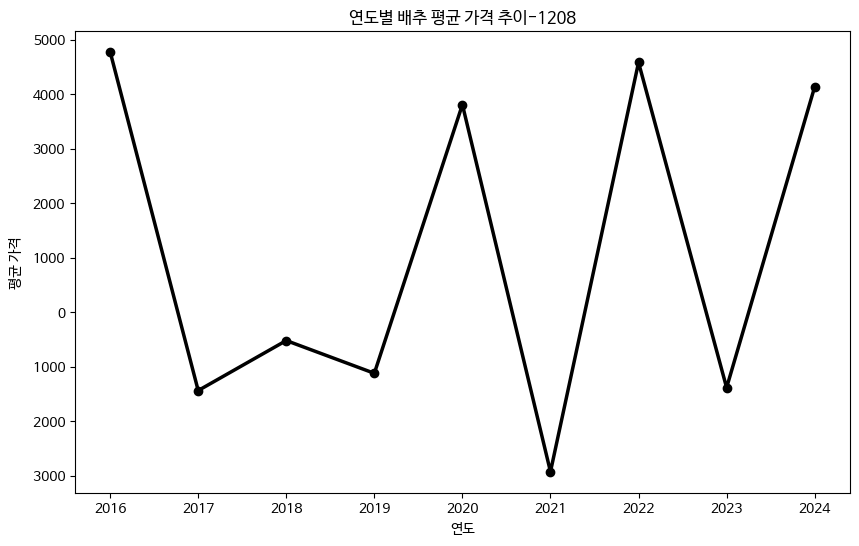

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df['exmn_dd_prc'] = pd.to_numeric(df['exmn_dd_prc'].astype(str))

# 1. 연도별 평균 가격 계산
year_price = df.groupby('year')['exmn_dd_prc'].mean().reset_index()


# 전년 대비 평균 가격 변화량(차이) 계산
year_price['exmn_dd_prc_diff'] = year_price['exmn_dd_prc'].diff()

# 선그래프 시각화
plt.figure(figsize=(10, 6))
plt.title('연도별 배추 평균 가격 추이-1208')
plt.xlabel('연도')
plt.ylabel('평균 가격')
plt.plot(year_price['year'], year_price['exmn_dd_prc_diff'], marker='o', linewidth=2.5, color='k')
plt.show()


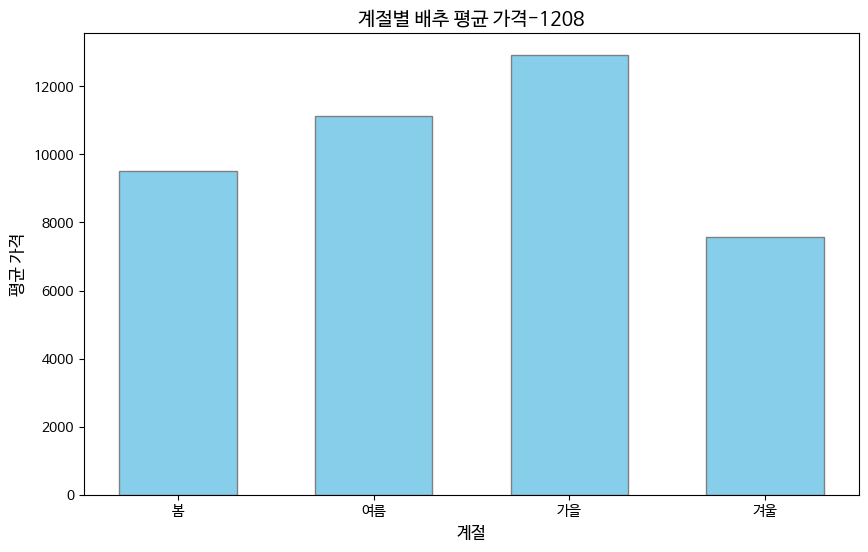

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

df['exmn_dd_prc'] = pd.to_numeric(df['exmn_dd_prc'].astype(str))

df['month'] = pd.to_datetime(df['exmn_ymd'].astype(str)).dt.month

def get_season(month):
    if month in [3, 4, 5]:
        return '봄'
    elif month in [6, 7, 8]:
        return '여름'
    elif month in [9, 10, 11]:
        return '가을'
    else:
        return '겨울'

df['season'] = df['month'].apply(get_season)

season_order = ['봄', '여름', '가을', '겨울']
season_price = df.groupby('season')['exmn_dd_prc'].mean().reindex(season_order).reset_index()

# 막대그래프 시각화
plt.figure(figsize=(10, 6))
bars = plt.bar(season_price['season'], season_price['exmn_dd_prc'], color='skyblue', edgecolor='gray', width=0.6)

plt.title('계절별 배추 평균 가격-1208', fontsize=14)
plt.xlabel('계절', fontsize=12)
plt.ylabel('평균 가격', fontsize=12)
plt.show()

In [ ]:
import pandas as pd

cabbage_items = response.json()['response']['body']['items']
if isinstance(cabbage_items, dict) and 'item' in cabbage_items:
    cabbage_list = cabbage_items['item']
else:
    cabbage_list = cabbage_items

df = pd.DataFrame(cabbage_list)

print(df.head())

  ctgry_cd ctgry_nm exmn_dd_cnvs_prc exmn_dd_prc  exmn_ymd grd_cd grd_nm  \
0      200      채소류             8400        8400  20240102     04     상품   
1      200      채소류             8600        8600  20240103     04     상품   
2      200      채소류             8400        8400  20240104     04     상품   
3      200      채소류             7000        7000  20240105     04     상품   
4      200      채소류             7600        7600  20240108     04     상품   

  item_cd item_nm  mrkt_cd mrkt_nm          orgnl_reg_dt se_cd se_nm sgg_cd  \
0     211      배추  0110211    가락도매  2024-01-02T15:35:35Z    02   중도매   1101   
1     211      배추  0110211    가락도매  2024-01-03T15:44:53Z    02   중도매   1101   
2     211      배추  0110211    가락도매  2024-01-04T16:10:23Z    02   중도매   1101   
3     211      배추  0110211    가락도매  2024-01-08T10:23:27Z    02   중도매   1101   
4     211      배추  0110211    가락도매  2024-01-08T15:38:11Z    02   중도매   1101   

  sgg_nm         unit unit_sz vrty_cd vrty_nm  
0     서울  kg(그물망 3포기

In [ ]:
import requests

url = "https://apis.data.go.kr/B552845/perDay/price?serviceKey={"20cfd8a0950ea26eab8982ed37f0d6b0d9c2dd6f91d681d7e9b0790c3c9fe207"}&pageNo=1&numOfR
ows=200&returnType=JSON&cond[exmn_ymd::GTE]=20150101&cond[exmn_ymd::LTE]=2015123
1&cond[se_cd::EQ]=02&cond[ctgry_cd::EQ]=200&cond[item_cd::EQ]=211&cond[grd_cd::EQ]=04
&cond[sgg_cd::EQ]=1101&cond[mrkt_cd::EQ]=0110211&cond[vrty_cd::EQ]=01"

# 4. API 호출 및 결과 확인
response = requests.get(url, params=params)

# JSON 형태로 변환 후 총 데이터 건수(totalCount) 확인
data = response.json()
print("총 데이터 건수:", data['response']['body']['totalCount'])


SyntaxError: invalid decimal literal (4115774058.py, line 3)

In [ ]:
import requests

url = "https://apis.data.go.kr/B552845/perDay"
api_key = "20cfd8a0950ea26eab8982ed37f0d6b0d9c2dd6f91d681d7e9b0790c3c9fe207"

params = {
    'serviceKey': api_key,
    'pageNo': '1',
    'numOfRows': '200',
    'returnType': 'JSON',
    'cond[se_cd::EQ]': '02',         # 구분코드: 중도매(도매)
    'cond[ctgry_cd::EQ]': '200',     # 부류코드: 채소류
    'cond[item_cd::EQ]': '211',      # 품목코드: 배추
    'cond[grd_cd::EQ]': '04',        # 등급코드: 상품
    'cond[sgg_cd::EQ]': '1101',      # 시군구코드: 서울
    'cond[mrkt_cd::EQ]': '0110211'   # 시장코드: 가락도매
}

    # 3. 과제 지시사항에 따른 '동작 확인 예시' 테스트 세팅 (2015년 봄배추 기준)
params['cond[exmn_ymd::GTE]'] = '20150101'
params['cond[exmn_ymd::LTE]'] = '20151231'
params['cond[vrty_cd::EQ]'] = '01'

# 4. API 호출 및 결과 확인
response = requests.get(url, params=params)

# JSON 형태로 변환 후 총 데이터 건수(totalCount) 확인
data = response.json()
print("총 데이터 건수:", data['response']['body']['totalCount'])

KeyError: 'response'